# Results: Feature Interpretation

In this notebook, we examine which features are selected as important by different feature selection methods.

In [13]:
import ast
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

In [9]:
# =============================
# Load per-fold result
# =============================
df = pd.read_csv("../results/2026-05-03_23-48-47_nhanes/metrics_nhanes_per_fold.csv")

# parse selected feature list
df["features"] = df["selected_features"].apply(ast.literal_eval)

# =============================
# Settings
# =============================
model = "logreg"
k = 5

methods = ["rfe", "shap", "cmim", "pid", "jmi"]

pretty_names = {
    "rfe": "RFE",
    "shap": "SHAP",
    "cmim": "CMIM",
    "pid": "PID",
    "jmi": "JMI"
}

# =============================
# Most frequent top-5 features per method
# =============================
rows = []

for method in methods:
    sub = df[
        (df["model"] == model)
        & (df["selector"] == method)
        & (df["k"] == k)
    ]

    cnt = Counter()
    for feats in sub["features"]:
        cnt.update(feats)

    top5 = [feat for feat, count in cnt.most_common(5)]
    top5 = sorted(top5)

    rows.append({
        "Method": pretty_names[method],
        "Top 5 Features": ", ".join(top5)
    })

top5_table = pd.DataFrame(rows)

display(top5_table)

,Method,Top 5 Features
0,RFE,"BMDAVSAD, BMXHT, BMXWAIST, RIDAGEYR, RIDRETH3_3.0"
1,SHAP,"BMXSAD2, BMXWAIST, DMDHHSZE, DMDHRAGE, RIDAGEYR"
2,CMIM,"BMXBMI, BMXWAIST, BMXWT, DMDHRAGE, RIDAGEYR"
3,PID,"BMXWAIST, INDFMPIR, MGXH1T2, PEASCTM1, RIDAGEYR"
4,JMI,"BMDAVSAD, BMXWAIST, BMXWT, DMDHRAGE, RIDAGEYR"


In [10]:
for method in methods:
    sub = df[
        (df["model"] == model)
        & (df["selector"] == method)
        & (df["k"] == k)
    ]

    cnt = Counter()
    for feats in sub["features"]:
        cnt.update(feats)

    # convert to DataFrame for inspection
    freq_df = pd.DataFrame(
        [(feat, count) for feat, count in cnt.items()],
        columns=["feature", "count"]
    ).sort_values(by="count", ascending=False)

    print(f"\n==== {pretty_names[method]} ====")
    display(freq_df)


==== RFE ====


,feature,count
0,RIDAGEYR,5
3,RIDRETH3_3.0,5
4,BMXHT,3
5,BMDAVSAD,3
1,BMXWAIST,2
2,MIAPROXY_2.0,1
6,MGXH1T3,1
7,RIDRETH3_7.0,1
8,RIDRETH1_3.0,1
9,BMXLEG,1



==== SHAP ====


,feature,count
0,RIDAGEYR,5
1,BMXWAIST,5
4,DMDHRAGE,5
2,BMXSAD2,4
3,DMDHHSZE,3
5,BMDAVSAD,3



==== CMIM ====


,feature,count
0,RIDAGEYR,5
1,BMXWAIST,5
2,BMXWT,5
4,DMDHRAGE,5
7,BMXBMI,2
3,INDHHIN2,1
5,MGXH1T3,1
6,PEASCTM1,1



==== PID ====


,feature,count
0,RIDAGEYR,5
1,BMXWAIST,5
2,INDFMPIR,3
6,PEASCTM1,3
3,MGXH1T2,2
5,INDFMIN2,2
7,MGXH2T1,2
4,BPXPLS,1
8,MGXH1T3,1
9,BPXDI_MEAN,1



==== JMI ====


,feature,count
0,RIDAGEYR,5
1,BMXWAIST,5
2,DMDHRAGE,5
3,BMDAVSAD,4
4,BMXWT,4
5,BMXSAD1,1
6,BMXBMI,1


In [11]:
# collect frequency table for all methods
all_freq = []

for method in methods:
    sub = df[
        (df["model"] == model)
        & (df["selector"] == method)
        & (df["k"] == k)
    ]

    cnt = Counter()
    for feats in sub["features"]:
        cnt.update(feats)

    for feat, count in cnt.items():
        all_freq.append({
            "method": pretty_names[method],
            "feature": feat,
            "count": count
        })

freq_all_df = pd.DataFrame(all_freq)

# use all features that appear in any method
all_features = (
    freq_all_df
    .groupby("feature")["count"]
    .sum()
    .sort_values(ascending=False)
    .index
)

# fill missing method-feature combinations with 0
full_df = (
    freq_all_df
    .pivot_table(index="feature", columns="method", values="count", fill_value=0)
    .reindex(all_features)
)

display(full_df)

method,CMIM,JMI,PID,RFE,SHAP
feature,,,,,
RIDAGEYR,5.0,5.0,5.0,5.0,5.0
BMXWAIST,5.0,5.0,5.0,2.0,5.0
DMDHRAGE,5.0,5.0,0.0,0.0,5.0
BMDAVSAD,0.0,4.0,0.0,3.0,3.0
BMXWT,5.0,4.0,0.0,0.0,0.0
RIDRETH3_3.0,0.0,0.0,0.0,5.0,0.0
PEASCTM1,1.0,0.0,3.0,0.0,0.0
BMXSAD2,0.0,0.0,0.0,0.0,4.0
MGXH1T3,1.0,0.0,1.0,1.0,0.0


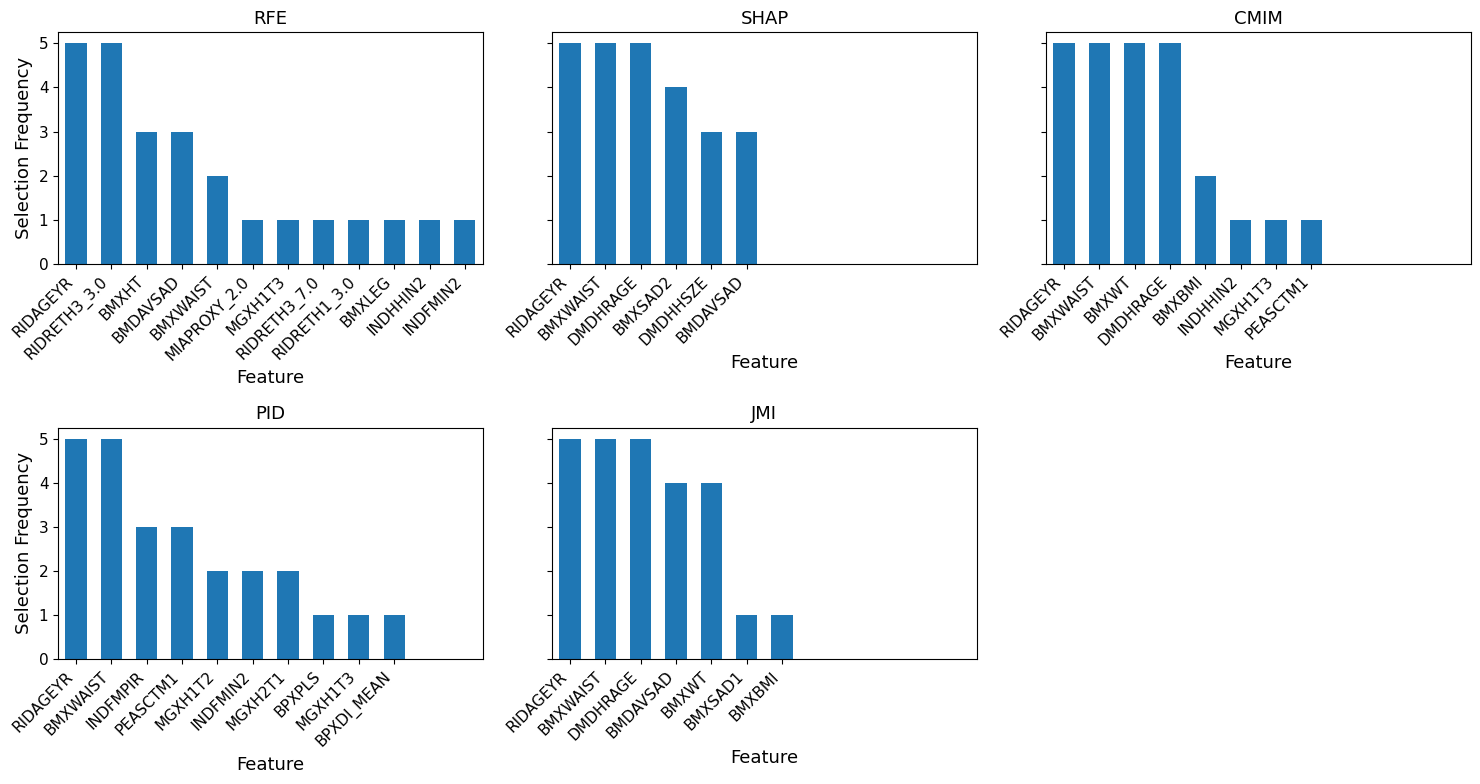

In [14]:
# =====================================
# Settings
# =====================================
model = "logreg"
k = 5

methods = ["rfe", "shap", "cmim", "pid", "jmi"]

pretty_names = {
    "rfe": "RFE",
    "shap": "SHAP",
    "cmim": "CMIM",
    "pid": "PID",
    "jmi": "JMI"
}

# =====================================
# Parse feature list if needed
# =====================================
# Uncomment if features are stored as strings
# df["features"] = df["features"].apply(ast.literal_eval)

# =====================================
# Count feature frequencies
# =====================================
all_freq = []

for method in methods:

    sub = df[
        (df["model"] == model)
        & (df["selector"] == method)
        & (df["k"] == k)
    ]

    cnt = Counter()

    for feats in sub["features"]:
        cnt.update(feats)

    for feat, count in cnt.items():
        all_freq.append({
            "method": pretty_names[method],
            "feature": feat,
            "count": count
        })

freq_all_df = pd.DataFrame(all_freq)

# =====================================
# Global settings
# =====================================
max_features = freq_all_df.groupby("method").size().max()
methods_unique = freq_all_df["method"].unique()

# dynamic subplot layout
n_methods = len(methods_unique)

n_cols = 3
n_rows = math.ceil(n_methods / n_cols)

# =====================================
# Create subplot grid
# =====================================
fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(5 * n_cols, 4 * n_rows),
    sharey=True
)

axes = axes.flatten()

# =====================================
# Plot each method
# =====================================
for ax, method_name in zip(axes, methods_unique):

    plot_df = (
        freq_all_df[freq_all_df["method"] == method_name]
        .sort_values("count", ascending=False)
        .reset_index(drop=True)
    )

    x = range(len(plot_df))

    ax.bar(
        x,
        plot_df["count"],
        width=0.6
    )

    # keep same visual width
    ax.set_xlim(-0.5, max_features - 0.5)

    ax.set_xticks(x)

    ax.set_xticklabels(
        plot_df["feature"],
        rotation=45,
        ha="right"
    )

    ax.set_title(method_name, fontsize=13)

    ax.set_xlabel("Feature")

# =====================================
# Only left-most plots show y-label
# =====================================
for i, ax in enumerate(axes[:n_methods]):
    if i % n_cols == 0:
        ax.set_ylabel("Selection Frequency")

# =====================================
# Hide unused subplot(s)
# =====================================
for ax in axes[n_methods:]:
    ax.axis("off")

# =====================================
# Final formatting
# =====================================
plt.tight_layout()

plt.show()

In [15]:
# =============================
# Load per-fold result
# =============================
df = pd.read_csv("../results/2026-05-03_23-48-47_nhanes/metrics_nhanes_per_fold.csv")
df["features"] = df["selected_features"].apply(ast.literal_eval)

# =============================
# Settings
# =============================
model = "logreg"
k = 5
freq_cutoff = 3

methods = ["rfe", "shap", "cmim", "pid", "jmi"]

pretty_names = {
    "rfe": "RFE",
    "shap": "SHAP",
    "cmim": "CMIM",
    "pid": "PID",
    "jmi": "JMI"
}

# =============================
# Features with count >= cutoff
# =============================
rows = []

for method in methods:
    sub = df[
        (df["model"] == model)
        & (df["selector"] == method)
        & (df["k"] == k)
    ]

    cnt = Counter()
    for feats in sub["features"]:
        cnt.update(feats)

    kept = [
        (feat, count)
        for feat, count in cnt.most_common()
        if count >= freq_cutoff
    ]

    rows.append({
        "Method": pretty_names[method],
        "Selected Features (count >= 3)": ", ".join(
            [f"{feat} ({count}/5)" for feat, count in kept]
        )
    })

overall_table = pd.DataFrame(rows)
display(overall_table)

,Method,Selected Features (count >= 3)
0,RFE,"RIDAGEYR (5/5), RIDRETH3_3.0 (5/5), BMXHT (3/5..."
1,SHAP,"RIDAGEYR (5/5), BMXWAIST (5/5), DMDHRAGE (5/5)..."
2,CMIM,"RIDAGEYR (5/5), BMXWAIST (5/5), BMXWT (5/5), D..."
3,PID,"RIDAGEYR (5/5), BMXWAIST (5/5), INDFMPIR (3/5)..."
4,JMI,"RIDAGEYR (5/5), BMXWAIST (5/5), DMDHRAGE (5/5)..."


In [16]:
# =============================
# Matrix format
# =============================
all_features = sorted(set(
    feat
    for row in rows
    for feat in [
        item.split(" (")[0]
        for item in row["Selected Features (count >= 3)"].split(", ")
        if item
    ]
))

matrix = []

for feat in all_features:
    row = {"Feature": feat}
    
    for method in methods:
        sub = df[
            (df["model"] == model)
            & (df["selector"] == method)
            & (df["k"] == k)
        ]

        cnt = Counter()
        for feats in sub["features"]:
            cnt.update(feats)

        count = cnt.get(feat, 0)
        row[pretty_names[method]] = f"{count}/5" if count >= freq_cutoff else "–"
    
    matrix.append(row)

matrix_table = pd.DataFrame(matrix)
display(matrix_table)

,Feature,RFE,SHAP,CMIM,PID,JMI
0,BMDAVSAD,3/5,3/5,–,–,4/5
1,BMXHT,3/5,–,–,–,–
2,BMXSAD2,–,4/5,–,–,–
3,BMXWAIST,–,5/5,5/5,5/5,5/5
4,BMXWT,–,–,5/5,–,4/5
5,DMDHHSZE,–,3/5,–,–,–
6,DMDHRAGE,–,5/5,5/5,–,5/5
7,INDFMPIR,–,–,–,3/5,–
8,PEASCTM1,–,–,–,3/5,–
9,RIDAGEYR,5/5,5/5,5/5,5/5,5/5


In [18]:
# =============================
# Feature code -> readable feature name
# =============================
feature_name_map = {
    "BMDAVSAD": "Abdominal fat measure",
    "BMXHT": "Height",
    "BMXSAD2": "Abdominal diameter",
    "BMXWAIST": "Waist circumference",
    "BMXWT": "Body weight",
    "DMDHHSZE": "Household size",
    "DMDHRAGE": "Household reference age",
    "INDFMPIR": "Income-to-poverty ratio",
    "PEASCTM1": "Physical activity time",
    "RIDAGEYR": "Age",
    "RIDRETH3_3.0": "Race / ethnicity",
}

# =============================
# Matrix format
# =============================
all_features = sorted(set(
    feat
    for row in rows
    for feat in [
        item.split(" (")[0]
        for item in row["Selected Features (count >= 3)"].split(", ")
        if item
    ]
))

matrix = []

for feat in all_features:
    row = {"Feature": feature_name_map.get(feat, feat)}
    
    for method in methods:
        sub = df[
            (df["model"] == model)
            & (df["selector"] == method)
            & (df["k"] == k)
        ]

        cnt = Counter()
        for feats in sub["features"]:
            cnt.update(feats)

        count = cnt.get(feat, 0)
        row[pretty_names[method]] = f"{count}/5" if count >= freq_cutoff else "–"
    
    matrix.append(row)

matrix_table = pd.DataFrame(matrix)
display(matrix_table)

,Feature,RFE,SHAP,CMIM,PID,JMI
0,Abdominal fat measure,3/5,3/5,–,–,4/5
1,Height,3/5,–,–,–,–
2,Abdominal diameter,–,4/5,–,–,–
3,Waist circumference,–,5/5,5/5,5/5,5/5
4,Body weight,–,–,5/5,–,4/5
5,Household size,–,3/5,–,–,–
6,Household reference age,–,5/5,5/5,–,5/5
7,Income-to-poverty ratio,–,–,–,3/5,–
8,Physical activity time,–,–,–,3/5,–
9,Age,5/5,5/5,5/5,5/5,5/5
